In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df=pd.read_csv('../data/heart.csv')

In [16]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [17]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

+ age = age of the patient
+ sex = gender of patient (1=Male,0=Female)
+ cp = Chest Pain type (0-3)
+ trestbps = Resting Blod Pressure (Blood Pressure of patient during rest period(mm Hg))
+ chol = Serum Cholestrol(Level of cholestrol in blood (mg/dl))
+ fbs = Fasting blood sugar(is the blood sugar is faster then 120 mg/dl(1=Yes,0=No))
+ restech = Resting Elecrocardigrapic result (result of ecg (0,1 or 2))
+ thalach = Max Heart rate acheived (max heart rate of the patient during exercise)
+ exang = Exercise Induced Angina (Is chest pain happens due to exercise (1=Yes,0=No))
+ oldpeak = Due to exercise ST  depression in ECG
+ slope = Slope of peak exercise ST segment
+ ca = Nummber of major vessels (Number of major blood vessel saw in Fluoroscopy (0 se 3 tak))
+ thal = Thalassemia ( blood disorder) type (like 1,2,3)
+ target = Tell there is heart disease or not to the patieint (1=Risk of heart disease,0=Healthy)


In [18]:
# checking the missin values in the data
print(df.isnull().sum())

# Checkking duplicate rows and column 
print("Duplicate rows:",df.duplicated())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Duplicate rows: 0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool


In [19]:
df.drop_duplicates(inplace =True)

In [20]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [21]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

<Axes: >

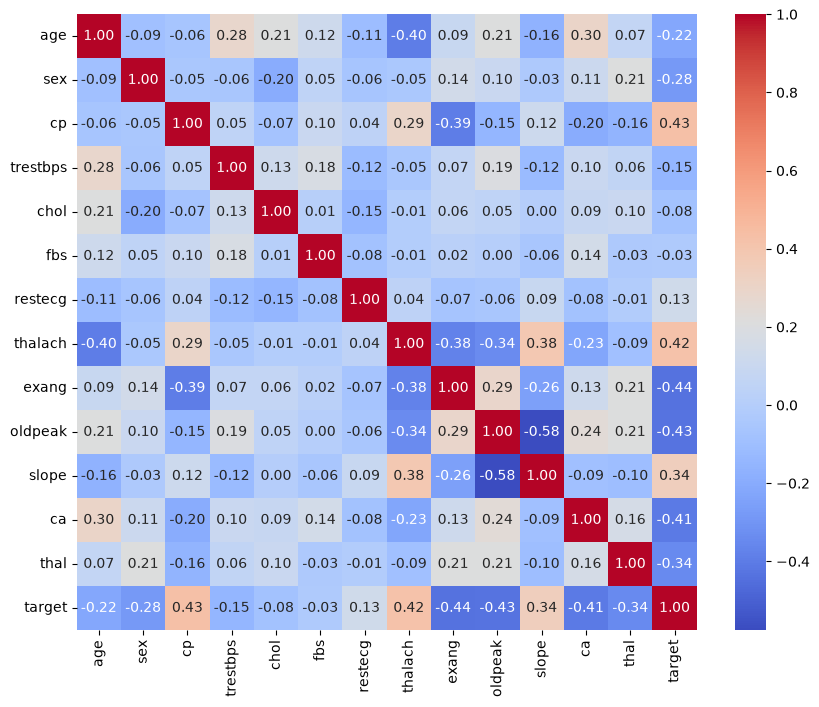

In [22]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

### Preprocessing and Standardization

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Making(X) dependent and Independent(y) Features
X=df.drop(columns=['target'])
y=df['target']

# Ding the tarin_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Feature Scaling 
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print("Data succesfully split and scaled!")
print("X_train.shape",X_train.shape)
print("X_test.shape",X_test.shape)

Data succesfully split and scaled!
X_train.shape (241, 13)
X_test.shape (61, 13)


### Comparing The different Models Accuracy(LogisticRegression,RandomForest,XGboost)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#1.Logistic Regession Model
lr_model=LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled,y_train)
lr_pred=lr_model.predict(X_test_scaled)
print(f"Logistic Regressio Acuuracy:{accuracy_score(y_test,lr_pred)*100:.2f}%")

#2.Random Forest Model
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled,y_train)
rf_pred=rf_model.predict(X_test_scaled)
print(f"Random Forest Accuracy:{accuracy_score(y_test,rf_pred)*100:.2f}%")

#3.Xgboost model
xgb_model=XGBClassifier(random_stat=42)
xgb_model.fit(X_train_scaled,y_train)
xgb_pred=xgb_model.predict(X_test_scaled)
print(f"xGboost Accuracy:{accuracy_score(y_test,xgb_pred)*100:.2f}%")

Logistic Regressio Acuuracy:77.05%
Random Forest Accuracy:83.61%
xGboost Accuracy:80.33%


In [28]:
#Saving the Model And Scaler value
import joblib

joblib.dump(rf_model,'model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']